In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time


In [81]:
# data upload and pass processing

f = 'melb_data.csv'
df_original = pd.read_csv(f)

#It's logical that the unit doesn`t have a land plot
df_original.loc[(df_original.Type == 'u') & (df_original.Landsize.isnull()),'Landsize'] = 0

#Missing parking info probably means no parking space is available
df_original["Car"] = df_original["Car"].fillna(0)


target_col = "Price"

feature_cols = [
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Lattitude",
    "Longtitude",
    "Propertycount",
]

df_base = df_original[feature_cols + [target_col]].copy()
df = df_base.dropna()




In [82]:
df = df.copy()

df["PriceClass"] = pd.qcut(df[target_col], q=4, labels=False).astype(int)

X = df[feature_cols]
y = df['PriceClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [83]:

n_features_original = X_train.shape[1]

clf = DecisionTreeClassifier(random_state=42)

start_train_orig = time.time()
clf.fit(X_train, y_train)
end_train_orig = time.time()

y_pred = clf.predict(X_test)
acc_original = accuracy_score(y_test, y_pred)
train_time_original = end_train_orig - start_train_orig

print(f"Original number of features: {n_features_original}")
print(f"Original accuracy: {acc_original:.4f}")
print(f"Original training time: {end_train_orig - start_train_orig:.4f}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.95)

start_pca = time.time()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
end_pca = time.time()

n_components = pca.n_components_
explained_variance = pca.explained_variance_ratio_.sum()

# Model with PCA
clf_pca = DecisionTreeClassifier(random_state=42)

start_train_pca = time.time()
clf_pca.fit(X_train_pca, y_train)
end_train_pca = time.time()

y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
train_time_pca = end_train_pca - start_train_pca

print(f"Number of components after PCA: {n_components}")
print(f"Accuracy after PCA: {acc_pca:.4f}")
print(f"Training time after PCA: {train_time_pca:.4f}")



Original number of features: 11
Original accuracy: 0.6399
Original training time: 0.0704
Number of components after PCA: 9
Accuracy after PCA: 0.5955
Training time after PCA: 0.0932


In [84]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_scaled)

pca2= PCA(n_components=2)
X_pca_n2 = pca2.fit_transform(X_train_scaled)


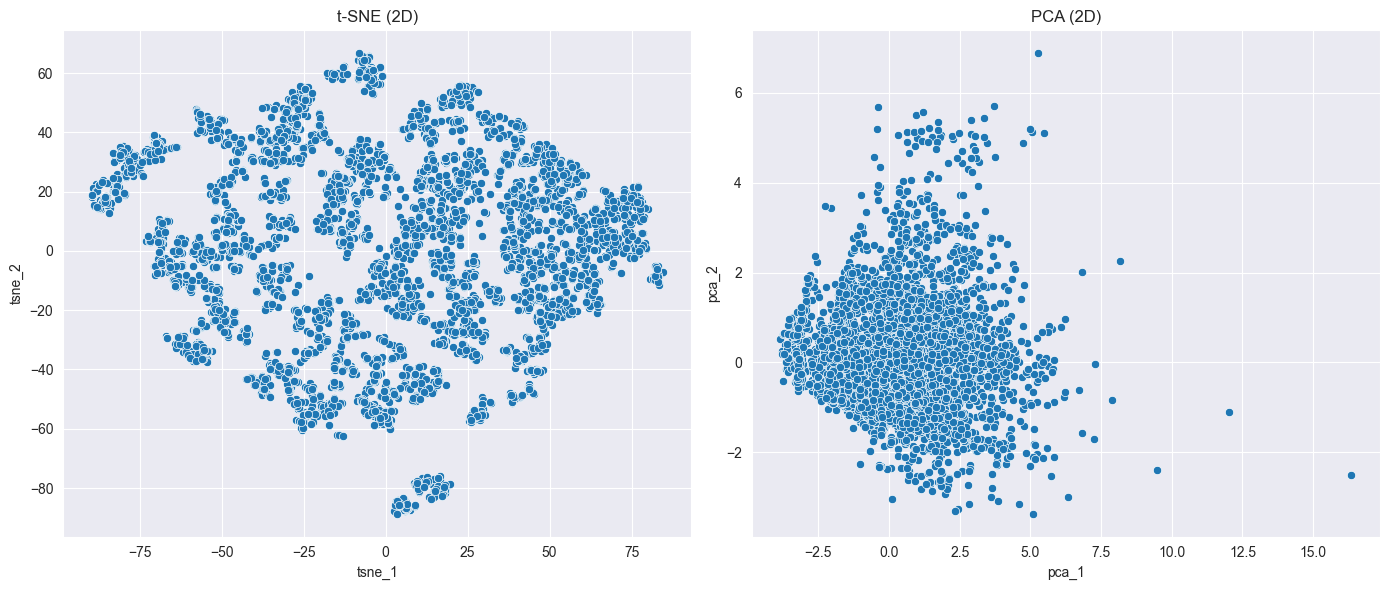

In [85]:
tsne_df = pd.DataFrame({"tsne_1": X_train_tsne[:, 0], "tsne_2": X_train_tsne[:, 1]})

pca_df = pd.DataFrame({"pca_1": X_pca_n2[:, 0], "pca_2": X_pca_n2[:, 1]})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=tsne_df, x="tsne_1", y="tsne_2", ax=axes[0])
axes[0].set_title("t-SNE (2D)")
sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", ax=axes[1])
axes[1].set_title("PCA (2D)")
plt.tight_layout()
plt.show()

Image shape: (799, 1280, 3)
dtype: uint8


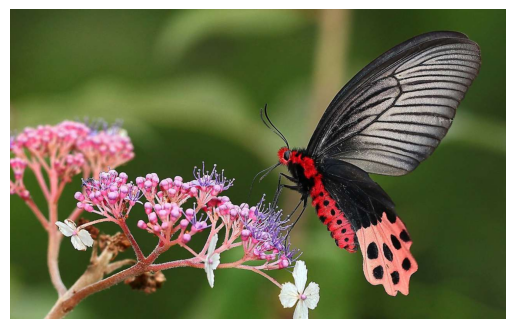

In [86]:
from matplotlib.image import imread
from sklearn.cluster import KMeans

img = imread("Image.jpg")
h, w, c = img.shape
print("Image shape:", img.shape)
print("dtype:", img.dtype)

plt.imshow(img)
plt.axis('off')
plt.show()


In [87]:

data = img / 255.0  # нормалізуємо до [0,1]
pixels = data.reshape(-1, 3)
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(pixels)

,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [88]:
def quantize_image_kmeans(pixels, k, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    kmeans.fit(pixels)
    new_pixels = kmeans.cluster_centers_[kmeans.labels_]
    return new_pixels

ks = [64, 32, 16, 8]
quantized_images = []

for k in ks:
    q_pixels = quantize_image_kmeans(pixels, k)
    q_img = q_pixels.reshape(h, w, c)
    quantized_images.append(q_img)


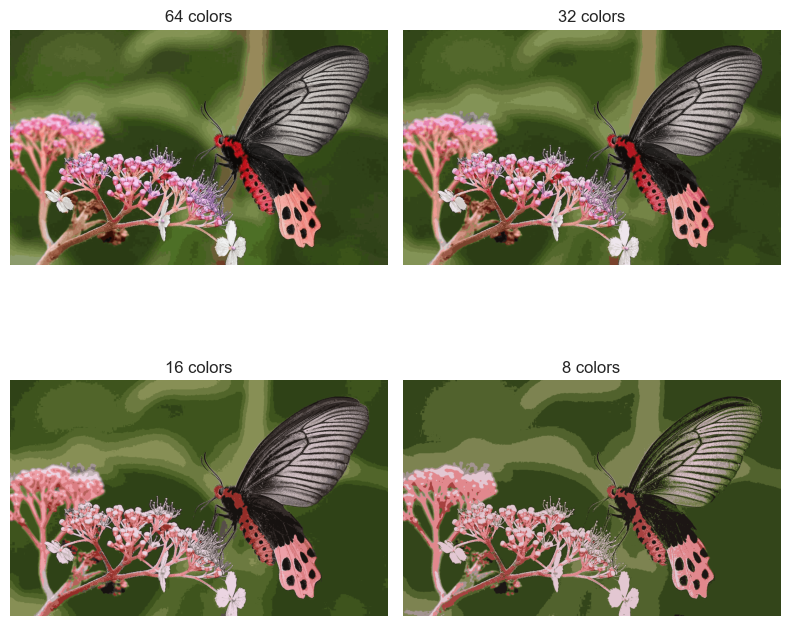

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, q_img, k in zip(axes.ravel(), quantized_images, ks):
    ax.imshow(q_img)
    ax.set_title(f"{k} colors")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [90]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df.rename(columns={"v1": "label", "v2": "text"})
df = df[["text", "label"]]
df.head()

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [91]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = ENGLISH_STOP_WORDS

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)
df.head()


,text,label,clean_text
0,"Go until jurong point, crazy.. Available only ...",ham,jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ham,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,ham,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",ham,nah don t think goes usf lives


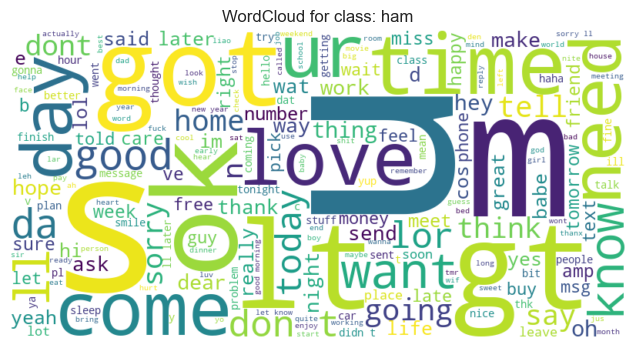

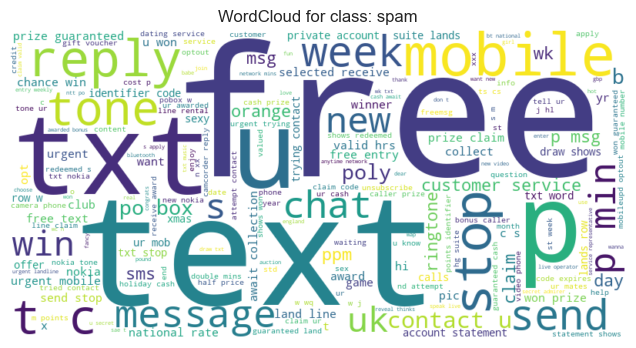

In [92]:
from wordcloud import WordCloud

labels = df["label"].unique()

for label in labels:
    texts = df.loc[df["label"] == label, "clean_text"]
    big_text = " ".join(texts)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(big_text)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for class: {label}")
    plt.show()

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and labels
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB(alpha=0.1)
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9829596412556054

Confusion matrix:
[[959   7]
 [ 12 137]]

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

